# Tugas 2 - Analisis Sinyal Suara & Noise Statis
**Nama:** Muharyan Syaifullah  
**NIM:** 123140045  
**Link GitHub:** https://github.com/MuharyanSyaifullah/stm-if25-40305-123140045/tree/main/02_audio_noise_statis

In [5]:
# library pendukung untuk menyimpan file wav
!pip install soundfile

# library yang dibutuhkan
import librosa
import librosa.display
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import soundfile as sf

# Memuat file audio dengan sample rate asli (sr=None agar tidak diubah otomatis)
audio_path = 'audio_original.wav'
y, sr = librosa.load(audio_path, sr=None)

# Menghitung durasi, jumlah sampel, serta amplitudo min & max
duration = librosa.get_duration(y=y, sr=sr)
total_samples = len(y)
min_amp = np.min(y)
max_amp = np.max(y)

# Mencetak informasi metadata ke layar
print("--- Inspeksi Metadata Audio ---")
print(f"Durasi: {duration:.2f} detik")
print(f"Laju sampel (fs): {sr} Hz")
print(f"Jumlah total sampel: {total_samples}")
print(f"Amplitudo Min: {min_amp:.4f}")
print(f"Amplitudo Max: {max_amp:.4f}")

--- Inspeksi Metadata Audio ---
Durasi: 29.40 detik
Laju sampel (fs): 48000 Hz
Jumlah total sampel: 1411071
Amplitudo Min: -0.3839
Amplitudo Max: 0.5440


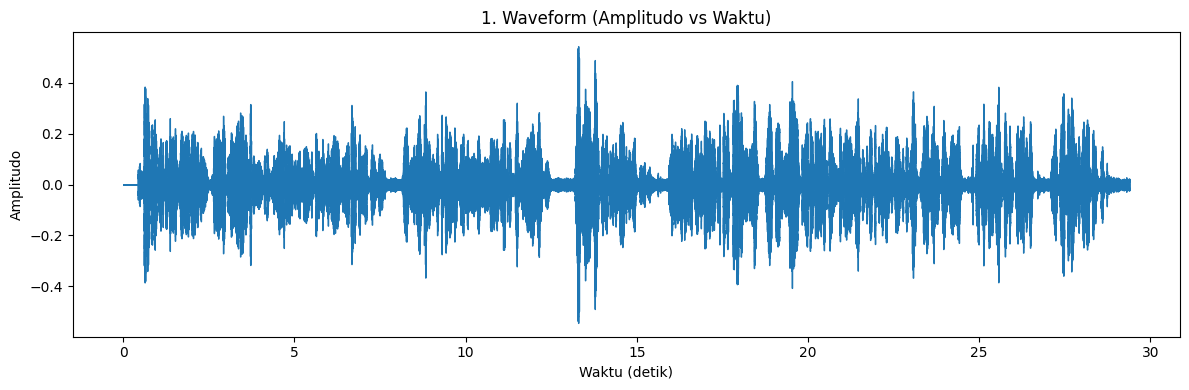

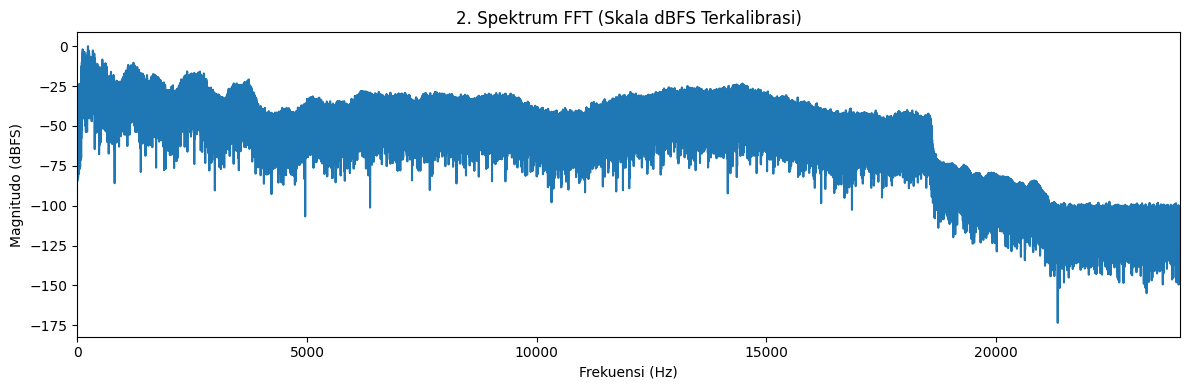

In [6]:
# === 1. PLOT WAVEFORM ===
plt.figure(figsize=(12, 4))
# Menampilkan grafik gelombang suara (amplitudo terhadap waktu)
librosa.display.waveshow(y, sr=sr)
plt.title('1. Waveform (Amplitudo vs Waktu)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.tight_layout()
plt.show()

# === 2. PLOT SPEKTRUM FFT (dBFS) ===
# Menghitung Fast Fourier Transform (FFT) dari sinyal
fft_out = np.fft.fft(y)
# Mengambil magnitudo absolut dari separuh spektrum (karena FFT simetris)
mag = np.abs(fft_out)
half_mag = mag[:len(mag)//2]
# Membuat sumbu X (frekuensi) dari 0 sampai batas Nyquist (fs/2)
freqs = np.linspace(0, sr/2, len(half_mag))

# Konversi magnitudo ke skala decibel Full Scale (dBFS), ditambah 1e-10 untuk cegah error log(0)
dbfs = 20 * np.log10(half_mag / np.max(half_mag) + 1e-10)

plt.figure(figsize=(12, 4))
# Menampilkan grafik frekuensi (Hz) vs Magnitudo (dBFS)
plt.plot(freqs, dbfs)
plt.title('2. Spektrum FFT (Skala dBFS Terkalibrasi)')
plt.xlabel('Frekuensi (Hz)')
plt.ylabel('Magnitudo (dBFS)')
plt.xlim([0, sr/2])
plt.tight_layout()
plt.show()

**Analisis Waveform & FFT:**
Berdasarkan plot waveform di atas, bagian hening yang berisi derau statis (noise floor) terlihat pada sekitar detik ke-8 hingga 9 dan detik ke-15, sedangkan suara vokal saya terlihat saat amplitudonya melonjak tajam pada detik ke-13. Pada plot Spektrum FFT, derau statis (seperti kipas/AC) paling mendominasi di kisaran frekuensi rendah, yaitu sekitar 0 - 500 Hz, yang ditunjukkan oleh puncak tertinggi di ujung kiri grafik.

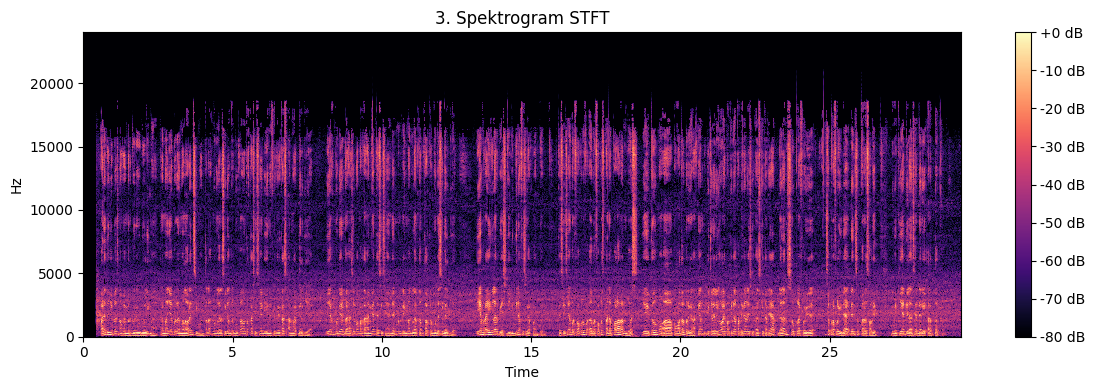

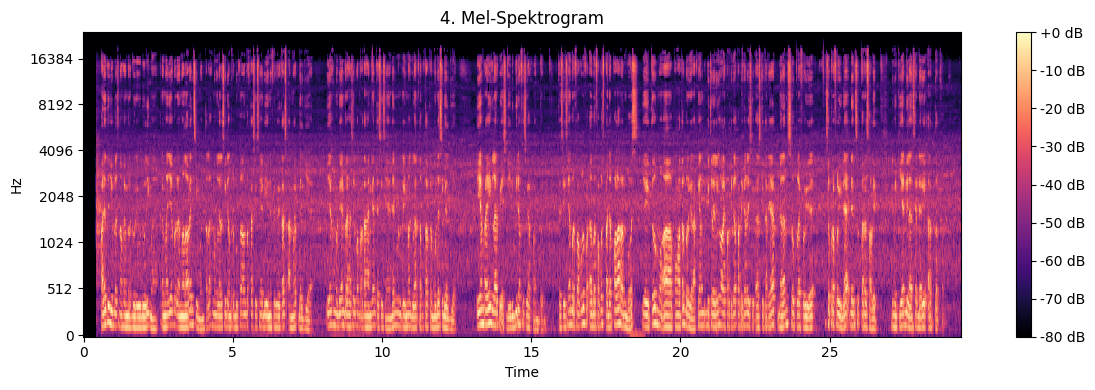

In [7]:
# === 3. PLOT SPEKTROGRAM STFT ===
# Menghitung Short-Time Fourier Transform (STFT)
D = librosa.stft(y)
# Mengonversi magnitudo ke desibel (dB)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
# Menampilkan spektrogram dengan sumbu Y frekuensi linier
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('3. Spektrogram STFT')
plt.tight_layout()
plt.show()

# === 4. PLOT MEL-SPEKTROGRAM ===
# Menghitung fitur Mel-spectrogram (menyesuaikan pendengaran manusia)
M = librosa.feature.melspectrogram(y=y, sr=sr)
# Mengonversi kekuatan Mel ke desibel (dB)
M_db = librosa.power_to_db(M, ref=np.max)

plt.figure(figsize=(12, 4))
# Menampilkan spektrogram dengan sumbu Y skala Mel
librosa.display.specshow(M_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('4. Mel-Spektrogram')
plt.tight_layout()
plt.show()

**Analisis Spektrogram & Mel-Spektrogram:**
Berdasarkan Spektrogram STFT di atas, derau statis terlihat jelas sebagai pita horizontal konstan berwarna keunguan di area paling bawah (frekuensi rendah). Namun karena skala STFT linier hingga 20.000 Hz, detail vokal menjadi kurang menonjol.

Sedangkan pada Mel-Spektrogram, formasi energi vokal saya (berwarna oranye/kuning terang) tampak jauh lebih padat, detail, dan mendominasi pada rentang 0 hingga 4000 Hz. Hal ini terjadi karena skala Mel dirancang logaritmik mengikuti cara kerja telinga manusia, yang memang lebih sensitif dalam menangkap detail dan membedakan frekuensi rendah-menengah tempat suara vokal manusia berada.


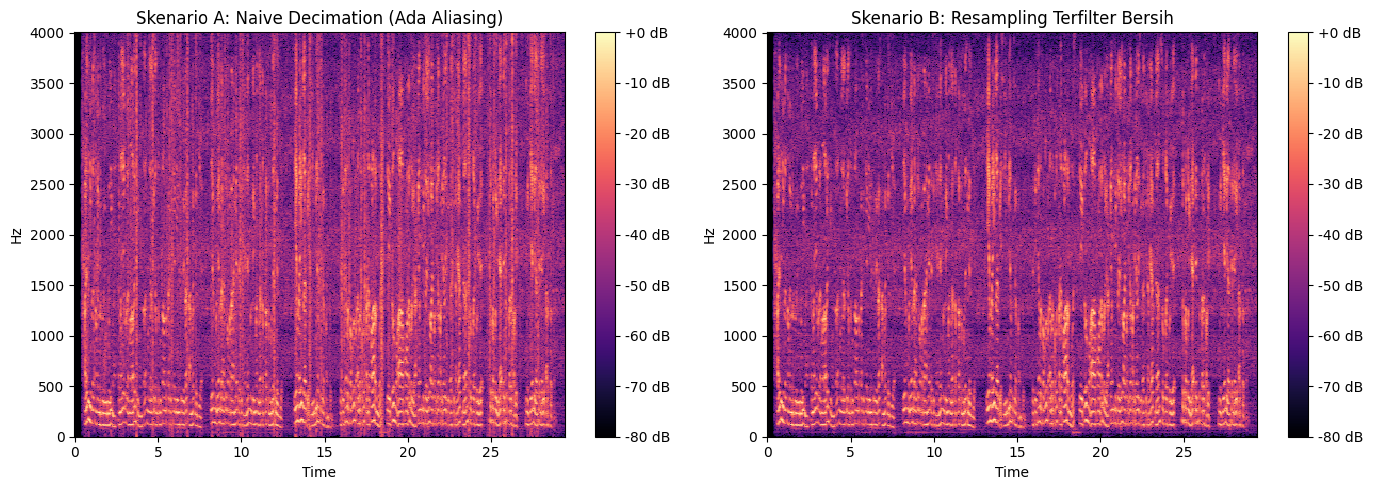

File audio hasil resampling selesai diekspor.


In [8]:
# Menentukan laju sampel target untuk downsampling (8 kHz)
target_sr = 8000
# Menghitung faktor pembagi / desimasi (M)
M = int(sr // target_sr)

# Skenario A: Naive Decimation (mengambil tiap sampel ke-M secara brutal tanpa filter)
y_naive = y[::M]

# Skenario B: Resampling Terfilter (menggunakan fungsi bawaan dengan filter anti-aliasing)
y_clean = scipy.signal.resample_poly(y, up=1, down=M)

# Menyiapkan 2 kanvas untuk komparasi spektrogram
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Memproses dan menampilkan Skenario A
D_naive = librosa.amplitude_to_db(np.abs(librosa.stft(y_naive)), ref=np.max)
img1 = librosa.display.specshow(D_naive, sr=target_sr, x_axis='time', y_axis='linear', ax=ax[0])
ax[0].set_title('Skenario A: Naive Decimation (Ada Aliasing)')
fig.colorbar(img1, ax=ax[0], format="%+2.f dB")

# Memproses dan menampilkan Skenario B
D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)
img2 = librosa.display.specshow(D_clean, sr=target_sr, x_axis='time', y_axis='linear', ax=ax[1])
ax[1].set_title('Skenario B: Resampling Terfilter Bersih')
fig.colorbar(img2, ax=ax[1], format="%+2.f dB")

plt.tight_layout()
plt.show()

# Ekspor kedua array audio hasil resampling ke file .wav baru
sf.write('audio_downsampled_naive.wav', y_naive, target_sr)
sf.write('audio_downsampled_clean.wav', y_clean, target_sr)
print("File audio hasil resampling selesai diekspor.")

**Analisis Eksperimen Aliasing:**
Berdasarkan perbandingan spektrogram di atas, batas frekuensi (Nyquist) baru berada di angka 4000 Hz karena laju sampel diturunkan menjadi 8 kHz. Pada Skenario A (Naive Decimation), terlihat jelas adanya efek aliasing. Komponen frekuensi tinggi dari sinyal asli yang berada di atas 4000 Hz tidak dibuang, sehingga "memantul" dan melipat masuk ke area bawahnya. Hal ini membuat area atas spektrogram (rentang 3000 - 4000 Hz) tampak lebih kotor dan dipenuhi bercak noise yang tidak beraturan.

Sebaliknya, spektrogram Skenario B tampak lebih bersih dan rapi di area batas atas (mendekati 4000 Hz). Ini membuktikan fungsi filter *Low-Pass* (anti-aliasing) yang sukses memotong frekuensi tinggi sebelum laju sampel diturunkan, sehingga mencegah terjadinya kebocoran/pantulan frekuensi.